# Per-plant SHAP top-feature map (paper revision)

Reads the per-plant SHAP CSVs produced by
`7_analysis/{us,world}/7_feature_importance_per_power_plant_plot_no_interference_no_stats.py`
and plots, in a 3-row layout:

- (a) U.S. scatter — top-1 SHAP feature per plant (171 plants)
- (b) U.S. 2° grid — dominant top feature per cell
- (c) Global scatter — top-1 SHAP feature per plant (1{,}065 plants)
- (d) Global 4° grid — dominant top feature per cell

Both scatter and grid panels share a unified feature→color map.
Output: `shap_per_plant_map.{pdf,png}` under
`/net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures/`.

In [1]:
import os
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.rcdefaults()
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16, 'axes.titlesize': 20,
    'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 11, 'figure.titlesize': 24,
    'axes.linewidth': 1.5,
    'axes.edgecolor': '#2c3e50', 'axes.labelcolor': '#2c3e50',
    'text.color': '#2c3e50',
})

# Register Nimbus Roman with matplotlib's font manager so we can refer to it
# by name in rcParams. Setting `font.family = 'Nimbus Roman'` directly fails
# silently and emits hundreds of warnings if the .otf isn't registered.
nimbus_path = None
for _p in fm.findSystemFonts():
    _pl = _p.lower()
    if ('nimbusroman' in _pl or 'nimbus_roman' in _pl) \
            and 'bold' not in _pl and 'italic' not in _pl and 'oblique' not in _pl:
        nimbus_path = _p; break
if nimbus_path:
    fm.fontManager.addfont(nimbus_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=nimbus_path).get_name()
    print('Registered:', plt.rcParams['font.family'], '->', nimbus_path)
else:
    print('Nimbus Roman not found; using matplotlib default')

# ── Paths (paper revision: new 100 m SHAP outputs) ───────────────────
US_SHAP_CSV     = ('/net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/'
                    'training_no_stats_item/feature_importance/'
                    'all_plants_contributions_constant_clean.csv')
WORLD_SHAP_CSV  = ('/net/fs06/d3/rzhuang/TROPOMI/data/world/pipeline_test_labelling_100m/'
                    'Run_100m_20260428/training_no_stats_item/feature_importance/'
                    'non_interfered_plants_contributions.csv')

OUT_DIR = '/net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures'
os.makedirs(OUT_DIR, exist_ok=True)


Registered: ['Nimbus Roman'] -> /usr/share/fonts/urw-base35/NimbusRoman-Regular.otf


In [2]:
# ── Feature names + groups + colors ──────────────────────────────────
feature_name_mapping = {
    'sensor_azimuth_angle': 'Sensor Azimuth Angle',
    'sensor_zenith_angle': 'Sensor Zenith Angle',
    'sensor_altitude': 'Sensor Altitude',
    'scaled_small_pixel_variance': 'Scaled Small-Pixel Variance',
    'annual_nox_emission': 'Annual NOx Emission',
    'hourly_emission_rate': 'Hourly NOx Emission',
    'NOx Mass (lbs)': 'Hourly NOx Emission',
    'wind_speed': 'Wind Speed',
    'cloud_albedo_crb': 'Cloud Albedo',
    'cloud_pressure_crb': 'Cloud Pressure',
    'cloud_fraction_crb': 'Cloud Fraction',
    'solar_zenith_angle': 'Solar Zenith Angle',
    'solar_azimuth_angle': 'Solar Azimuth Angle',
    'apparent_scene_pressure': 'Apparent Scene Pressure',
    'aerosol_index_354_388': 'Aerosol Index',
    't2m': '2 m Temperature',
    'tcwv': 'Total Column Water Vapour',
    'tisr': 'TOA Incident Solar Radiation',
    'surface_classification': 'Surface Classification',
    'surface_pressure': 'Surface Pressure',
    'snow_ice_flag': 'Snow/Ice Flag',
    'scene_albedo': 'Scene Albedo',
    'surface_albedo_nitrogendioxide_window': r'Surface Albedo (NO$_2$ Window)',
    'surface_albedo': 'Surface Albedo',
    'surface_altitude': 'Surface Altitude',
    'surface_altitude_precision': 'Surface Altitude Precision',
    'primary_fuel_type': 'Primary Fuel Type',
}

feature_groups = {
    'sensor': {
        'features': ['sensor_azimuth_angle','sensor_zenith_angle','sensor_altitude',
                      'scaled_small_pixel_variance'],
        'colors': ['#FF1493','#FF69B4','#FFB6C1','#FFC0CB','#FFE4E1'],
    },
    'power_plant': {
        'features': ['annual_nox_emission','hourly_emission_rate','NOx Mass (lbs)',
                      'primary_fuel_type'],
        'colors': ['#00FF00','#32CD32','#228B22','#006400','#2E8B57'],
    },
    'meteorology': {
        'features': ['wind_speed','cloud_albedo_crb','cloud_pressure_crb','cloud_fraction_crb',
                      'surface_pressure','solar_zenith_angle','solar_azimuth_angle',
                      'apparent_scene_pressure','aerosol_index_354_388','t2m','tcwv','tisr'],
        'colors': ['#87CEEB','#4682B4','#4169E1','#0000FF','#000080'],
    },
    'environment': {
        'features': ['surface_classification','snow_ice_flag','scene_albedo',
                      'surface_albedo_nitrogendioxide_window','surface_albedo',
                      'surface_altitude','surface_altitude_precision'],
        'colors': ['#FFFF00','#FFD700','#FFC300','#FFA500','#FF8C00','#FF6347','#FF4500',
                    '#FF2F00','#FF0000'],
    },
    'other': {'features': [], 'colors': ['#696969','#808080','#A9A9A9','#C0C0C0','#D3D3D3']},
}

def fade_color(hex_color, fade=0.5):
    h = hex_color.lstrip('#')
    rgb = [int(h[i:i+2], 16)/255. for i in (0,2,4)]
    faded = [c + (1-c)*fade for c in rgb]
    return '#%02x%02x%02x' % tuple(int(v*255) for v in faded)

def assign_group(name):
    for g, info in feature_groups.items():
        if name in info['features']:
            return g
    return 'other'

def create_color_map(features, fade=0.5):
    feats = sorted(set([f for f in features if pd.notna(f)]))
    cm, idx = {}, {g: 0 for g in feature_groups}
    for f in feats:
        g = assign_group(f)
        palette = feature_groups[g]['colors']
        cm[f] = fade_color(palette[idx[g] % len(palette)], fade)
        idx[g] += 1
    return cm

In [3]:
# ── Load SHAP CSVs (one file per region; same columns used for scatter + grid) ──
print('Loading SHAP CSVs ...')
df_us = pd.read_csv(US_SHAP_CSV)
df_gl = pd.read_csv(WORLD_SHAP_CSV)
print(f'  U.S.:   {len(df_us):,} plants | cols: {len(df_us.columns)}')
print(f'  Global: {len(df_gl):,} plants | cols: {len(df_gl.columns)}')

# Sanity: ensure required columns
required = ['latitude','longitude','top_1_feature','top_1_direction']
for name, d in [('US', df_us), ('Global', df_gl)]:
    miss = [c for c in required if c not in d.columns]
    if miss:
        # The original SHAP scripts use 'plant_id' for the location and may use
        # 'top_{i}_feature'/'top_{i}_direction'. Match if present.
        print(f'  WARNING [{name}]: missing {miss}')

# Use top_1_feature for the scatter
df_us['top_feat'] = df_us['top_1_feature']
df_gl['top_feat'] = df_gl['top_1_feature']

Loading SHAP CSVs ...
  U.S.:   171 plants | cols: 57
  Global: 1,065 plants | cols: 57


In [4]:
# ── Grid aggregation: dominant top feature per cell ──────────────────
def analyze_grid(df, grid_size, n_top=4):
    d = df.dropna(subset=['latitude','longitude']).copy()
    d['lon_bin'] = (d['longitude'] // grid_size) * grid_size
    d['lat_bin'] = (d['latitude']  // grid_size) * grid_size
    feat_cols = [f'top_{i}_feature'   for i in range(1, n_top+1) if f'top_{i}_feature'   in d.columns]
    dir_cols  = [f'top_{i}_direction' for i in range(1, n_top+1) if f'top_{i}_direction' in d.columns]

    def summarize(cell):
        feats = pd.melt(cell, value_vars=feat_cols)['value']
        dirs  = pd.melt(cell, value_vars=dir_cols )['value'] if dir_cols else pd.Series([None]*len(feats))
        comb = pd.DataFrame({'feature': feats.values, 'direction': dirs.values}).dropna()
        if comb.empty:
            return pd.Series({'top_1_feat': None, 'top_1_dir': None})
        top_feat = comb['feature'].value_counts().idxmax()
        dom_dir = comb[comb['feature']==top_feat]['direction'].mode()
        arrow = '↑' if (not dom_dir.empty and dom_dir.iloc[0]=='increases') else '↓'
        return pd.Series({'top_1_feat': top_feat, 'top_1_dir': arrow})

    return d.groupby(['lon_bin','lat_bin']).apply(summarize).reset_index()

print('Aggregating grids ...')
us_grid = analyze_grid(df_us, grid_size=2.0)
gl_grid = analyze_grid(df_gl, grid_size=4.0)
print(f'  U.S. grid cells:   {len(us_grid):,}')
print(f'  Global grid cells: {len(gl_grid):,}')

us_bounds = {'lon': [-130,-65], 'lat': [22,52]}
gl_bounds = {'lon': [-180,180], 'lat': [-60,80]}
def filter_bounds(g, b):
    return g[(g['lon_bin']>=b['lon'][0])&(g['lon_bin']<b['lon'][1])&
             (g['lat_bin']>=b['lat'][0])&(g['lat_bin']<b['lat'][1])].copy()
us_grid_f = filter_bounds(us_grid, us_bounds)
gl_grid_f = filter_bounds(gl_grid, gl_bounds)

# Unified color map
all_feats = pd.concat([us_grid_f['top_1_feat'], gl_grid_f['top_1_feat'],
                        df_us['top_feat'],       df_gl['top_feat']],
                       ignore_index=True).dropna().unique()
color_map = create_color_map(all_feats, fade=0.5)
print(f'  Color map covers {len(color_map)} features')

Aggregating grids ...
  U.S. grid cells:   97
  Global grid cells: 440
  Color map covers 18 features


In [5]:
# ── Map setup helpers ────────────────────────────────────────────────
def setup_us_map(ax, title):
    ax.set_extent([*us_bounds['lon'], *us_bounds['lat']], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='#fafafa')
    ax.add_feature(cfeature.OCEAN, facecolor='#e8f4ff', alpha=0.6)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, color='#34495e', alpha=0.8)
    ax.add_feature(cfeature.STATES, linewidth=0.8, edgecolor='#7f8c8d', alpha=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=1.5, edgecolor='#2c3e50', alpha=0.7)
    gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.3, linewidth=0.5, color='#95a5a6')
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = {'size': 18, 'color': '#34495e'}
    gl.ylabel_style = {'size': 18, 'color': '#34495e'}
    ax.set_title(title, fontsize=24, pad=10, weight='600', color='#000000')

def setup_world_map(ax, title):
    ax.set_extent([*gl_bounds['lon'], *gl_bounds['lat']], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='#fafafa')
    ax.add_feature(cfeature.OCEAN, facecolor='#e8f4ff', alpha=0.6)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.0, color='#34495e', alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='#7f8c8d', alpha=0.5)
    ax.add_feature(cfeature.LAKES, facecolor='#e8f4ff', edgecolor='#34495e', linewidth=0.5, alpha=0.6)
    ax.add_feature(cfeature.RIVERS, edgecolor='#5dade2', linewidth=0.5, alpha=0.5)
    gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.3, linewidth=0.5, color='#95a5a6')
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = {'size': 18, 'color': '#34495e'}
    gl.ylabel_style = {'size': 18, 'color': '#34495e'}
    ax.set_title(title, fontsize=24, pad=10, weight='600', color='#000000')

def frame(ax):
    ax.add_patch(plt.Rectangle((0.02,0.02),0.96,0.96, transform=ax.transAxes,
                                fill=False, edgecolor='#e0e0e0', linewidth=2, zorder=10))

def plot_scatter(ax, df, top_k=9, pt_size=15, jitter=0.2):
    d = df.dropna(subset=['top_feat','latitude','longitude']).copy()
    counts = d['top_feat'].value_counts()
    feats = counts.head(top_k).index.tolist()
    rng = np.random.default_rng(0)
    for i, feat in enumerate(feats):
        sub = d[d['top_feat']==feat]
        if len(sub)==0: continue
        jl = rng.normal(0, jitter, len(sub))
        jt = rng.normal(0, jitter, len(sub))
        ax.scatter(sub['longitude']+jl, sub['latitude']+jt,
                    transform=ccrs.PlateCarree(), s=pt_size,
                    color=color_map.get(feat, '#C0C0C0'), alpha=0.75, zorder=5+i)
    return counts

def plot_grid(ax, grid_df, cell_size):
    for _, r in grid_df.iterrows():
        if pd.isna(r['top_1_feat']): continue
        rect = Rectangle((r['lon_bin'], r['lat_bin']), cell_size, cell_size,
                          facecolor=color_map.get(r['top_1_feat'], 'lightgrey'),
                          edgecolor='black', linewidth=0.3, alpha=0.75,
                          transform=ccrs.PlateCarree())
        ax.add_patch(rect)
        if pd.notna(r['top_1_dir']):
            arrow_color = 'darkgreen' if r['top_1_dir']=='↑' else 'darkred'
            ax.text(r['lon_bin']+cell_size/2, r['lat_bin']+cell_size/2, r['top_1_dir'],
                    ha='center', va='center', fontsize=8, color=arrow_color,
                    fontweight='bold', transform=ccrs.PlateCarree(), zorder=10)

def make_legend(ax, items, ncol=3, bbox_y=-0.08, title='Top Features'):
    patches = [mpatches.Patch(color=color_map.get(f, '#C0C0C0'),
                                label=f'{feature_name_mapping.get(f, f)} ({c:,})',
                                edgecolor='white', linewidth=1.5)
               for f, c in items]
    leg = ax.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, bbox_y),
                    ncol=ncol, frameon=True, fancybox=True, shadow=True,
                    prop={'size':12,'weight':'500'}, title=title, title_fontsize=14,
                    columnspacing=2.0, handletextpad=0.8, handlelength=2.0)
    leg.get_frame().set_facecolor('#ffffff')
    leg.get_frame().set_edgecolor('#e0e0e0')
    leg.get_frame().set_linewidth(1.5)
    leg.get_frame().set_alpha(0.95)
    leg.get_title().set_color('#000000')
    leg.get_title().set_fontweight('bold')

Saved: /net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures/shap_per_plant_map.pdf
Saved: /net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures/shap_per_plant_map.png


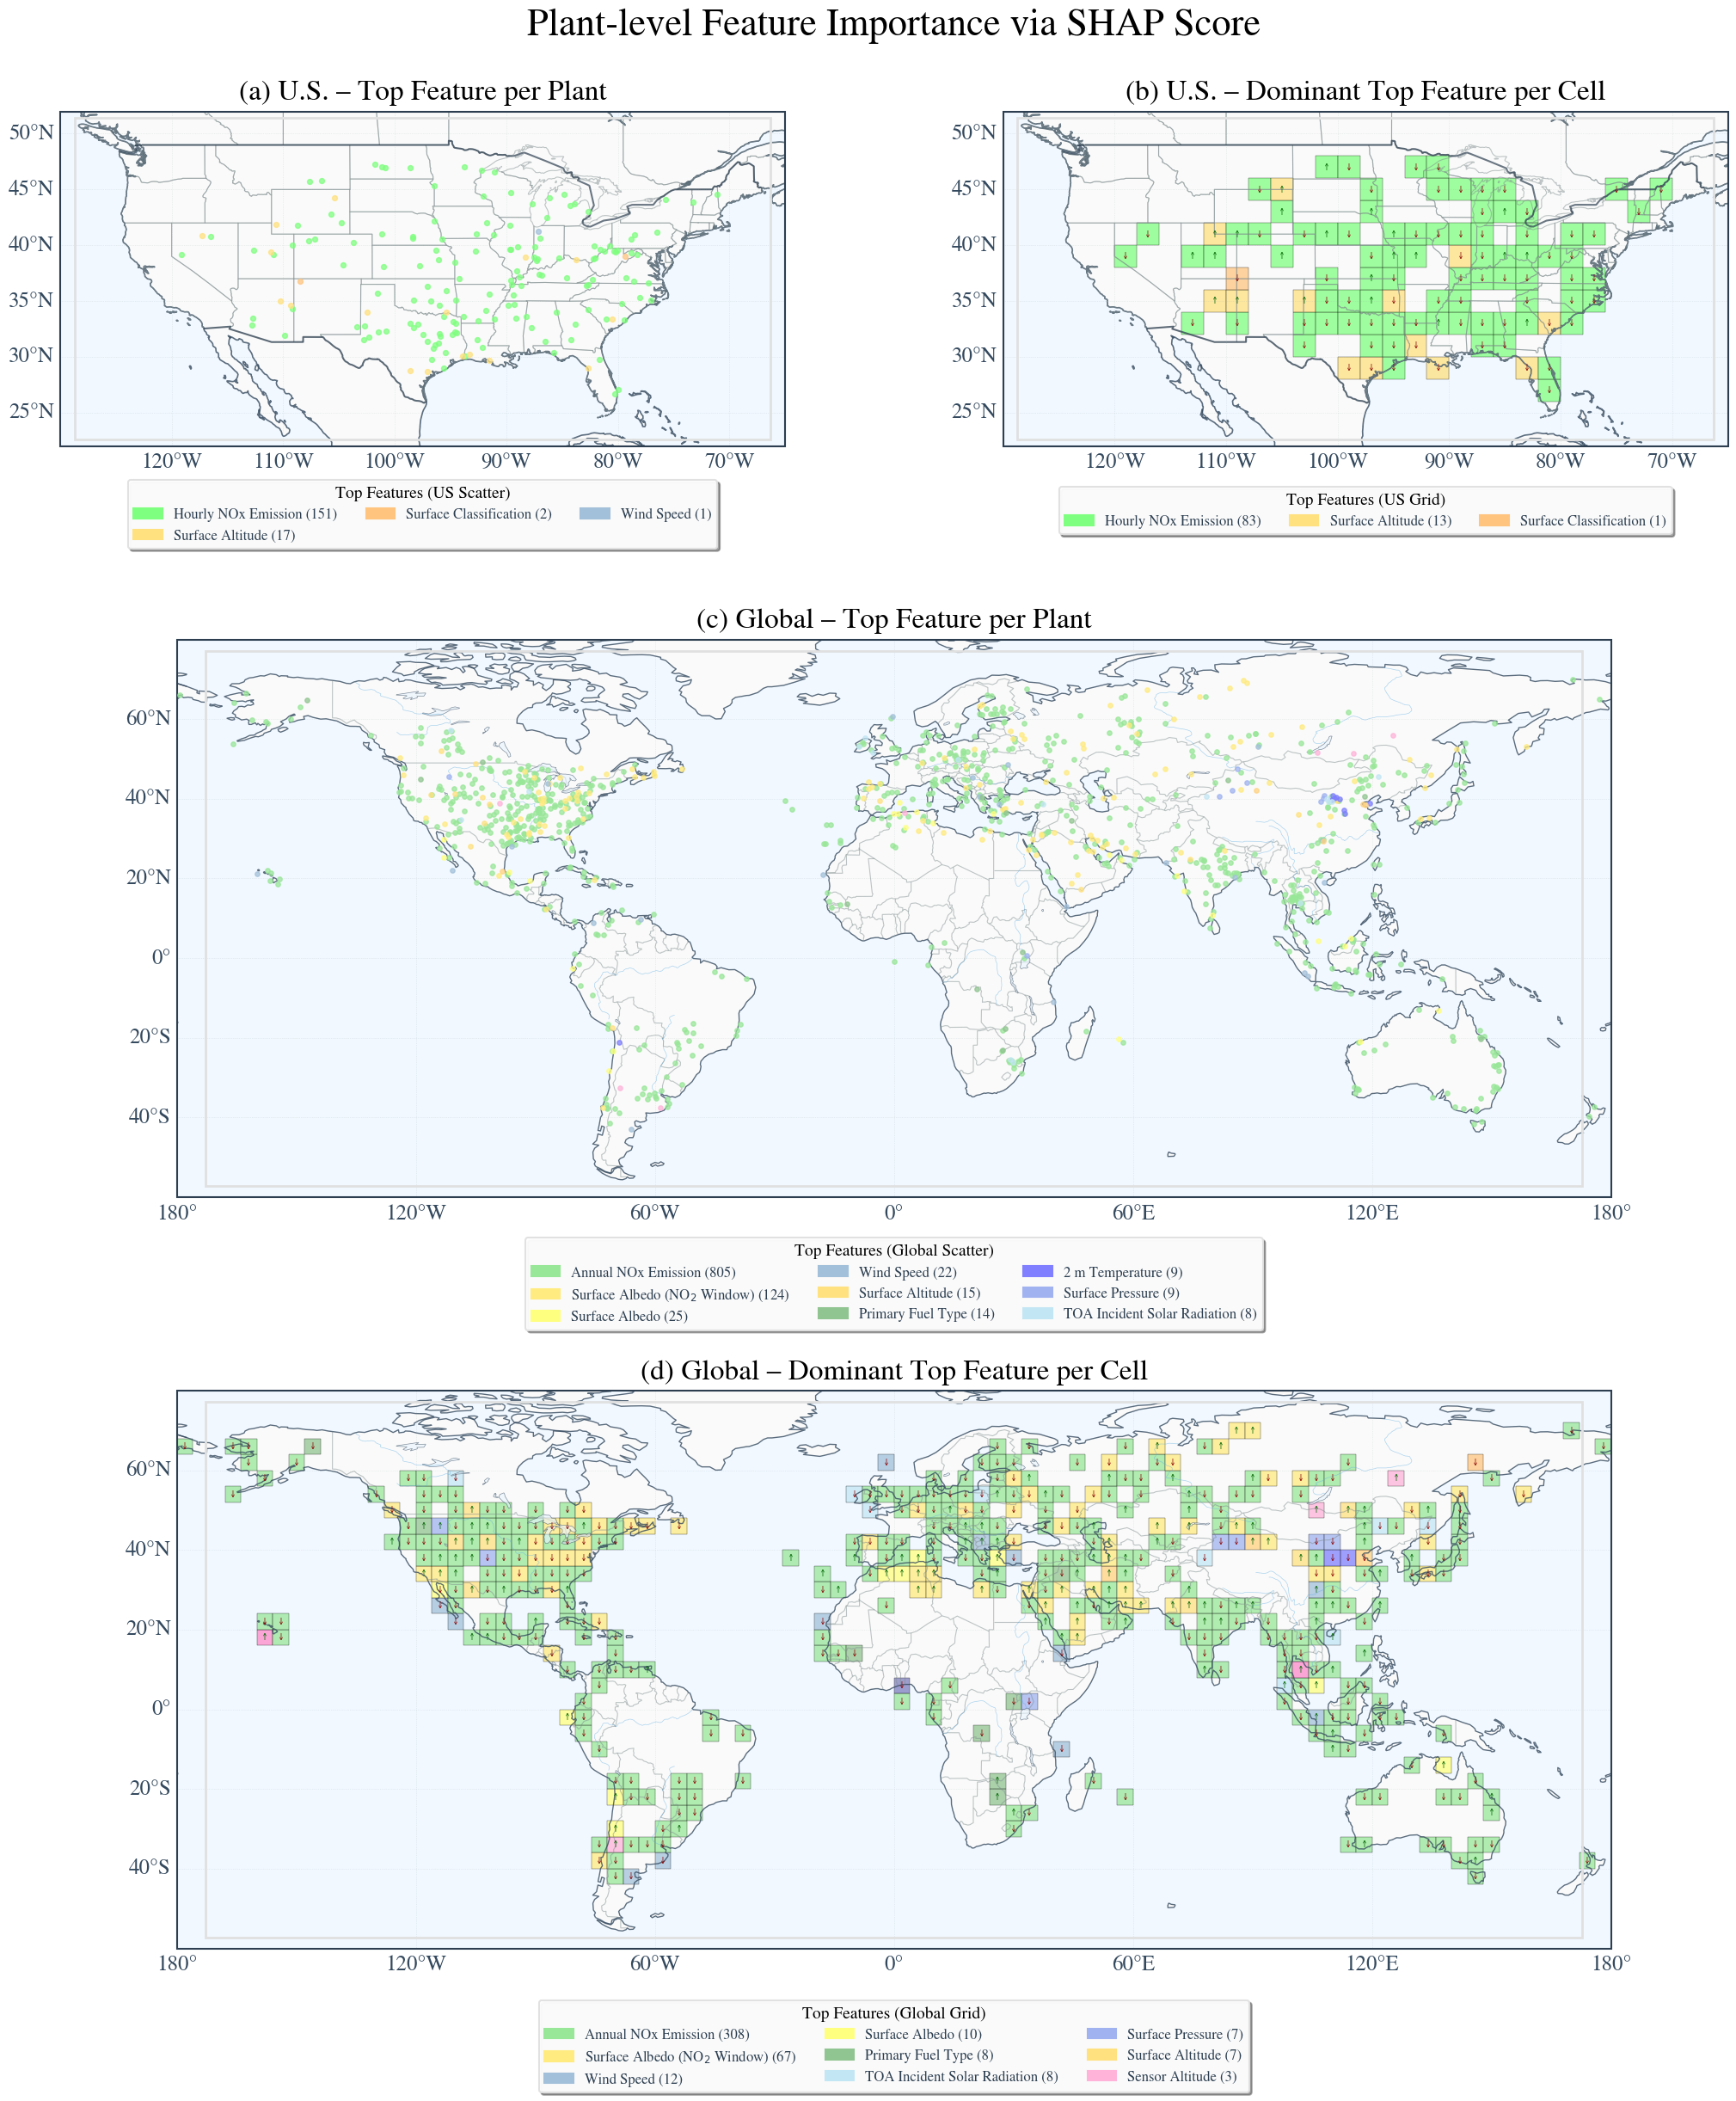

In [6]:
# ── Build the 3-row figure ───────────────────────────────────────────
fig = plt.figure(figsize=(22, 24), facecolor='white')
fig.suptitle('Plant-level Feature Importance via SHAP Score',
              fontsize=32, y=0.98, weight='bold', color='#000')

gs = GridSpec(nrows=3, ncols=2, height_ratios=[0.6, 1, 1], width_ratios=[1, 1],
              top=0.93, bottom=0.04, left=0.02, right=0.98, hspace=0.4, wspace=0.08)

ax_us_scatter = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax_us_grid    = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
ax_gl_scatter = fig.add_subplot(gs[1, 0:2], projection=ccrs.PlateCarree())
ax_gl_grid    = fig.add_subplot(gs[2, 0:2], projection=ccrs.PlateCarree())

setup_us_map(ax_us_scatter,    '(a) U.S. – Top Feature per Plant')
setup_us_map(ax_us_grid,       '(b) U.S. – Dominant Top Feature per Cell')
setup_world_map(ax_gl_scatter, '(c) Global – Top Feature per Plant')
setup_world_map(ax_gl_grid,    '(d) Global – Dominant Top Feature per Cell')

us_counts = plot_scatter(ax_us_scatter, df_us, top_k=9,  pt_size=18, jitter=0.10)
plot_grid(ax_us_grid, us_grid_f, cell_size=2.0)
gl_counts = plot_scatter(ax_gl_scatter, df_gl, top_k=12, pt_size=15, jitter=0.50)
plot_grid(ax_gl_grid, gl_grid_f, cell_size=4.0)

make_legend(ax_us_scatter, list(us_counts.head(9).items()),
             ncol=3, bbox_y=-0.08, title='Top Features (US Scatter)')
make_legend(ax_us_grid,    list(us_grid_f['top_1_feat'].value_counts().head(9).items()),
             ncol=3, bbox_y=-0.10, title='Top Features (US Grid)')
make_legend(ax_gl_scatter, list(gl_counts.head(9).items()),
             ncol=3, bbox_y=-0.06, title='Top Features (Global Scatter)')
make_legend(ax_gl_grid,    list(gl_grid_f['top_1_feat'].value_counts().head(9).items()),
             ncol=3, bbox_y=-0.08, title='Top Features (Global Grid)')

for ax in (ax_us_scatter, ax_us_grid, ax_gl_scatter, ax_gl_grid):
    frame(ax)

plt.tight_layout()
out_pdf = os.path.join(OUT_DIR, 'shap_per_plant_map.pdf')
out_png = os.path.join(OUT_DIR, 'shap_per_plant_map.png')
plt.savefig(out_pdf, dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(out_png, dpi=300, bbox_inches='tight', facecolor='white')
print(f'Saved: {out_pdf}')
print(f'Saved: {out_png}')
plt.show()